In [44]:
import matplotlib.pyplot as plt

from rgfn.gfns.reaction_gfn.api.data_structures import Molecule
import json

import pandas as pd
import json

cost_df = pd.read_csv('real_costs_csv.csv')
cost_df['Fragment'] = cost_df['Fragment'].apply(lambda x: Molecule(x).smiles)
cost_df['price per 1 mmol'] = cost_df['price per 1 mmol'].apply(lambda x: x.replace(',', '.'))

In [45]:
from rgfn import ReactionDataFactory

fragments_old = ReactionDataFactory(
    reaction_path='../../data/rgfn_old/chemistry.xlsx',
).get_fragments()
fragments_old = [x.smiles for x in fragments_old]

fragments_new = ReactionDataFactory(
    reaction_path='../../data/rgfn_new/chemistry.xlsx',
).get_fragments()
fragments_new = [x.smiles for x in fragments_new]

Using 350 fragments, 66 reactions, and 132 anchored reactions
Using 418 fragments, 117 reactions, and 223 anchored reactions


In [46]:
cost_df[cost_df['price per 1 mmol'].astype(float) <= 0]

,Fragment,Unnamed: 1,price of the original building block per gram:,price of the original building block per specific weight:,weight,lowest price per gram:,vendor,comments (for searching purposes),Total Molweight,price per 1 mmol
46,O=Cc1ccccc1,NaN,9,for 500 ml,NaN,NaN,sigma,NaN,"106,124",0
312,N#Cc1ccc(C(=O)O)cn1,NaN,70,NaN,NaN,NaN,oakwood,NaN,"148,121",0


In [47]:
# replace 0 cost with the 0.001
cost_df['price per 1 mmol'] = cost_df['price per 1 mmol'].apply(lambda x: x if float(x) > 0 else 0.001)

(array([313.,  40.,  23.,   8.,   8.,  10.,   5.,   4.,   5.,   2.,   3.,
          1.,   0.,   0.,   1.,   2.,   0.,   0.,   1.,   0.,   1.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,
          0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,   1.,   0.,
          1.]),
 array([1.00000000e-03, 1.95735100e+00, 3.91370200e+00, 5.87005300e+00,
        7.82640400e+00, 9.78275500e+00, 1.17391060e+01, 1.36954570e+01,
        1.56518080e+01, 1.76081590e+01, 1.95645100e+01, 2.15208610e+01,
        2.34772120e+01, 2.54335630e+01, 2.73899140e+01, 2.93462650e+01,
        3.13026160e+01, 3.3258

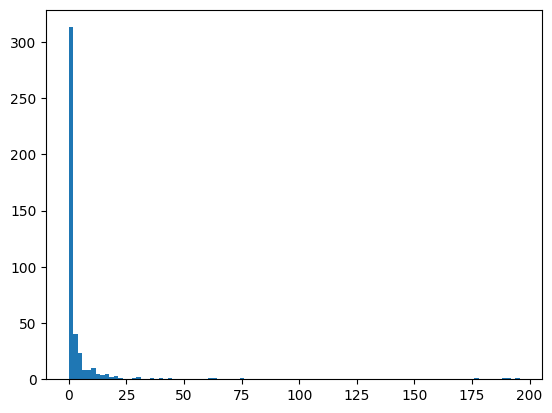

In [48]:
plt.hist(cost_df['price per 1 mmol'].astype(float), bins=100)

In [49]:
len(cost_df)

435

In [52]:
fragment_to_cost_dict = {row['Fragment']: float(row['price per 1 mmol']) for i, row in cost_df.iterrows()}
fragment_to_cost_dict_old = {k: v for k, v in fragment_to_cost_dict.items() if k in fragments_old}
fragment_to_cost_dict_new = {k: v for k, v in fragment_to_cost_dict.items() if k in fragments_new}

In [53]:
json.dump(fragment_to_cost_dict_new, open('../../data/rgfn_new/fragment_to_real_cost.json', 'w'), indent=2)
json.dump(fragment_to_cost_dict_old, open('../../data/rgfn_old/fragment_to_real_cost.json', 'w'), indent=2)